In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = os.path.join("..", "data", "StudentsPerformance.csv")
OUTPUT_DIR = os.path.join("..", "outputs", "resultados")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Registros:", df.shape[0])
print("Columnas:", df.shape[1])
print("\nNombres de columnas:")
print(list(df.columns))

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

Registros: 1000
Columnas: 8

Nombres de columnas:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Tipos de datos:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Valores faltantes:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicados: 0


In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df.describe(include="object")

/tmp/ipykernel_29149/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [6]:
# Quitar duplicados si los hubiera
df = df.drop_duplicates().reset_index(drop=True)

# Renombrar columnas con un diccionario explícito
mapa_columnas = {
    "gender": "gender",
    "race/ethnicity": "race_ethnicity",
    "parental level of education": "parental_level_of_education",
    "lunch": "lunch",
    "test preparation course": "test_preparation_course",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score",
}
df = df.rename(columns=mapa_columnas)
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [7]:
columnas_score = ["math_score", "reading_score", "writing_score"]
df["average_score"] = df[columnas_score].mean(axis=1)
df[["math_score", "reading_score", "writing_score", "average_score"]].head()

,math_score,reading_score,writing_score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


In [8]:
# Criterio: <60 Bajo | 60-79 Medio | >=80 Alto
# (60 = aprobatorio estándar, 80 = desempeño sobresaliente en escala 0-100)

def clasificar_rendimiento(promedio):
    if promedio < 60:
        return "Bajo"
    elif promedio < 80:
        return "Medio"
    else:
        return "Alto"

df["performance_level"] = df["average_score"].apply(clasificar_rendimiento)
df["performance_level"].value_counts()

performance_level
Medio    517
Bajo     285
Alto     198
Name: count, dtype: int64

In [9]:
promedios_area = df[columnas_score].mean().sort_values(ascending=False)
print(promedios_area)

reading_score    69.169
writing_score    68.054
math_score       66.089
dtype: float64


In [10]:
comparacion_prep = df.groupby("test_preparation_course")["average_score"].agg(
    ["mean", "median", "std", "count"]
).round(2)
comparacion_prep

,mean,median,std,count
test_preparation_course,,,,
completed,72.67,73.50,13.04,358
none,65.04,65.33,14.19,642


In [11]:
promedio_por_educacion = (
    df.groupby("parental_level_of_education")["average_score"]
    .mean().sort_values(ascending=False).round(2)
)
promedio_por_educacion

parental_level_of_education
master's degree       73.60
bachelor's degree     71.92
associate's degree    69.57
some college          68.48
some high school      65.11
high school           63.10
Name: average_score, dtype: float64

In [12]:
umbral = 80
pct_sobre_umbral = (df["average_score"] >= umbral).mean() * 100
print(f"Porcentaje con average_score >= {umbral}: {pct_sobre_umbral:.2f}%")


Porcentaje con average_score >= 80: 19.80%


In [13]:
promedio_por_grupo = df.groupby("race_ethnicity")["average_score"].mean().sort_values(ascending=False).round(2)
promedio_por_genero = df.groupby("gender")["average_score"].mean().round(2)
print(promedio_por_grupo)
print(promedio_por_genero)

race_ethnicity
group E    72.75
group D    69.18
group C    67.13
group B    65.47
group A    62.99
Name: average_score, dtype: float64
gender
female    69.57
male      65.84
Name: average_score, dtype: float64


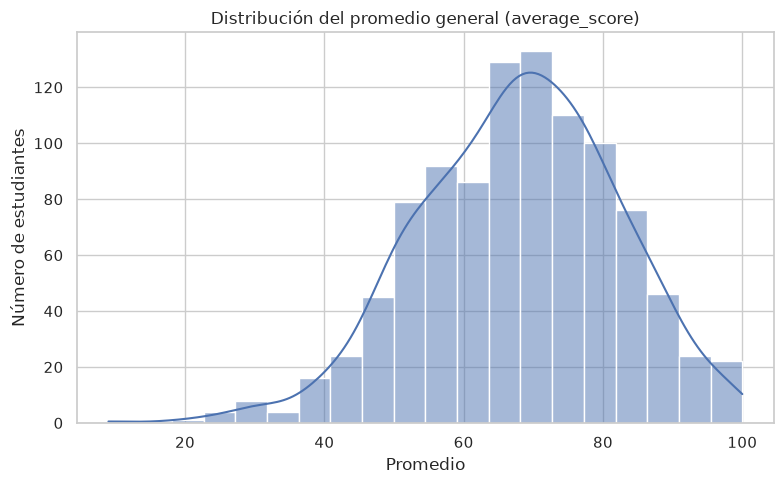

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["average_score"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribución del promedio general (average_score)")
plt.xlabel("Promedio")
plt.ylabel("Número de estudiantes")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_distribucion_average_score.png"), dpi=150)
plt.show()

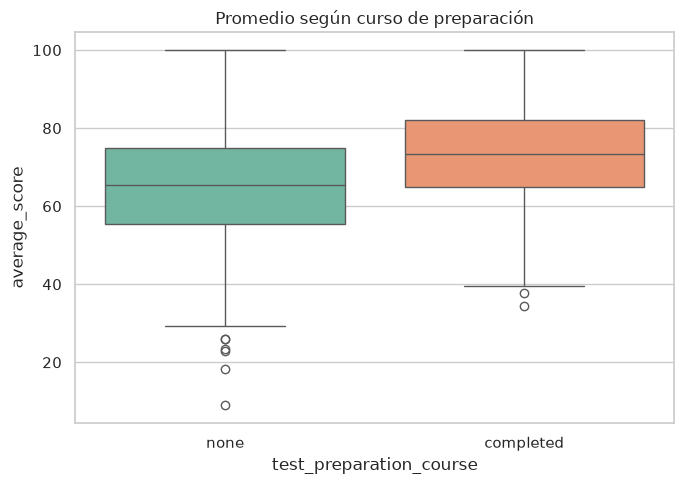

In [15]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="test_preparation_course", y="average_score",
            hue="test_preparation_course", palette="Set2", legend=False)
plt.title("Promedio según curso de preparación")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_boxplot_test_preparation.png"), dpi=150)
plt.show()


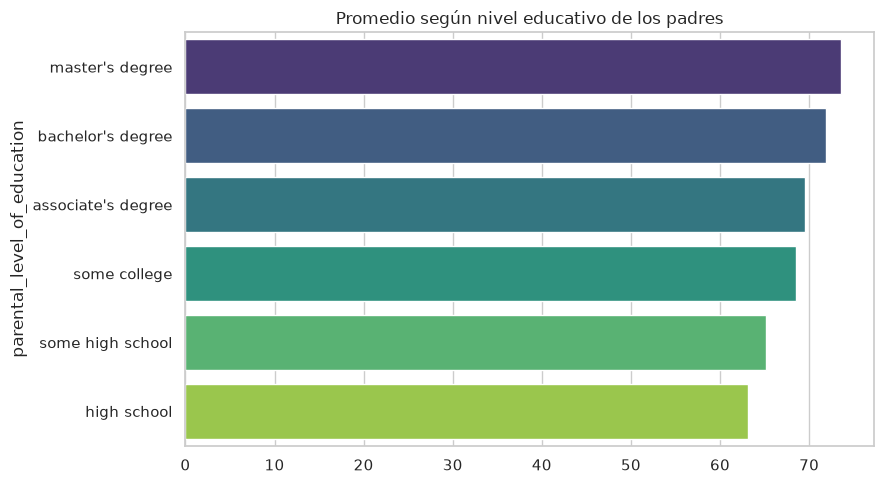

In [16]:
plt.figure(figsize=(9, 5))
orden = promedio_por_educacion.index
sns.barplot(x=promedio_por_educacion.values, y=orden, hue=orden, palette="viridis", legend=False)
plt.title("Promedio según nivel educativo de los padres")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_promedio_por_educacion_padres.png"), dpi=150)
plt.show()

In [18]:
df.to_csv(os.path.join(OUTPUT_DIR, "dataset_procesado.csv"), index=False)

# Conclusiones.
